In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plp
import seaborn as sns

### Getting the data 

In [4]:
data='ArithmeticErrorhttps://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [5]:
df= pd.read_csv('car_fuel_efficiency_2026.csv')

### Preparing the dataset

In [6]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
#selecting sepcific columns
df=df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

In [8]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [9]:
df.dtypes


engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [10]:
print(len(df))

10000


In [11]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [12]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


### EDA

In [13]:
# printing features
for col in df.columns:
    print(col)
    print(df[col].head())
    print(df[col].unique()[:5])
    print(df[col].nunique())

engine_displacement
0    2180
1    2390
2    2320
3    2130
4    2580
Name: engine_displacement, dtype: int64
[2180 2390 2320 2130 2580]
127
horsepower
0    243.0
1    272.0
2    267.0
3    258.0
4    304.0
Name: horsepower, dtype: float64
[243. 272. 267. 258. 304.]
153
vehicle_weight
0    3870
1    4210
2    4240
3    4490
4    4510
Name: vehicle_weight, dtype: int64
[3870 4210 4240 4490 4510]
176
model_year
0    2006
1    2008
2    1996
3    1989
4    1994
Name: model_year, dtype: int64
[2006 2008 1996 1989 1994]
50
fuel_efficiency_mpg
0    31.9
1    31.3
2    27.5
3    28.5
4    31.0
Name: fuel_efficiency_mpg, dtype: float64
[31.9 31.3 27.5 28.5 31. ]
188


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

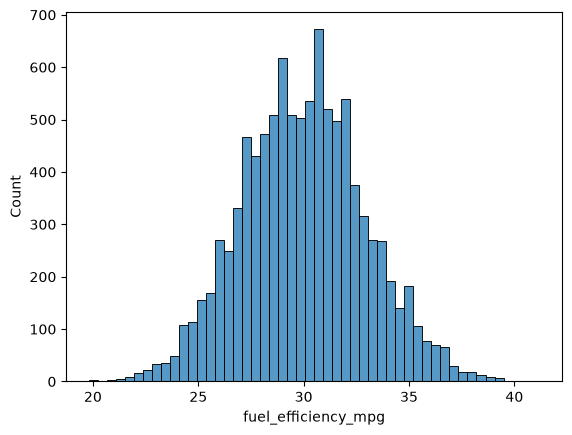

In [14]:
#distribution of  fuel efficiency

sns.histplot(df.fuel_efficiency_mpg,bins=50)

In [15]:
df["fuel_efficiency_mpg"].skew()

np.float64(0.08080419601878173)

The fuel efficiency distribution is symmetrical, so it doesn't require any transformation.

### Setting up the validation framework

In [16]:
n=len(df)
n_test=int(n*0.20)
n_val=int(n*0.20)
n_train=n-n_test-n_val

In [17]:
#assuring the randomness of splitting. 
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [ ]:
#splitting the dataset
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)


#prepare splitting

In [19]:
len(df_train)

6000

In [20]:
#multiplication of 2 vector
def dot(xi,w):

    res=0.0
    n=len(xi)

    for j in range(n):
        res=res+xi[j]*w[j]

    return res

In [21]:
#training a linear regression
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

### training model baseline with 0 for Nan

In [22]:
y_train=df_train.fuel_efficiency_mpg.values
y_val=df_val.fuel_efficiency_mpg.values
y_test=df_test.fuel_efficiency_mpg.values

In [23]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [24]:
#removing the target values from the dataframe
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']

In [25]:
#getting X_train values
X_train=df_train.fillna(0).values


In [26]:
w0,w= train_linear_regression(X_train,y_train)

RMSE

In [27]:
#implementation
def rmse(y,y_pred):
    error=y_pred-y
    se=error**2
    mse=se.mean()

    return np.sqrt(mse)


Evaluation

In [28]:
X_val=df_val.fillna(0).values

In [29]:
y_pred=w0+X_val.dot(w)

In [30]:
rmse(y_val,y_pred)

np.float64(2.205293194751098)

### training model baseline with mean for Nan

In [31]:
horsepower_mean = df_train['horsepower'].mean()

X_train_mean = df_train.fillna({'horsepower': horsepower_mean}).values
X_val_mean   = df_val.fillna({'horsepower': horsepower_mean}).values

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse(y_val, y_pred_mean)


np.float64(2.201817484568115)

### Regularization

In [32]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [43]:
def prepare_X(df):
    X=df.fillna(0).values
    return X


In [ ]:
reg=[0, 0.01, 0.1, 1, 5, 10, 100]

for r in reg: 
    
    w0,w=train_linear_regression_reg(X_train,y_train,r)
    y_pred=w0 + X_val.dot(w)
    
    print(f'r:{r},w0:{w0:.4f},score:{rmse(y_val, y_pred):.4f}')

r:0,w0:-153.8850,score:2.2053
r:0.01,w0:-148.3092,score:2.2058
r:0.1,w0:-111.8387,score:2.2241
r:1,w0:-32.3319,score:2.3492
r:5,w0:-7.7729,score:2.4094
r:10,w0:-3.9871,score:2.4195
r:100,w0:-0.4082,score:2.4292


### Question 5-Variation of seed

In [61]:
def prepare_split(seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx].reset_index(drop=True)
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    df_test = df_shuffled.iloc[n_train + n_val:].copy()

    y_train = df_train.pop('fuel_efficiency_mpg').values
    y_val = df_val.pop('fuel_efficiency_mpg').values
    y_test = df_test.pop('fuel_efficiency_mpg').values

    return df_train, df_val, df_test, y_train, y_val, y_test






In [63]:
seed=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores= []
for s in seed:
    df_train, df_val, df_test, y_train, y_val, y_test = prepare_split(s)

    X_train = prepare_X(df_train)
    X_val = prepare_X(df_val)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)
    print(f'seed:{s}, w0:{w0:.4f}, score:{score:.4f}')

print('std:', round(np.std(scores), 3))

seed:0, w0:-150.4289, score:2.2392
seed:1, w0:-151.6123, score:2.2021
seed:2, w0:-152.8407, score:2.1634
seed:3, w0:-152.3330, score:2.2044
seed:4, w0:-158.8886, score:2.2019
seed:5, w0:-151.8574, score:2.2458
seed:6, w0:-154.3718, score:2.2697
seed:7, w0:-155.0184, score:2.1908
seed:8, w0:-150.4382, score:2.2166
seed:9, w0:-154.3601, score:2.2070
std: 0.029


### Question 6- Testing model

In [80]:
df_train, df_val, df_test, y_train, y_val, y_test = prepare_split(9)
df_train_full=pd.concat([df_train,df_val]).reset_index(drop=True)
y_train_full=np.concatenate([y_train,y_val])
X_train_full= prepare_X(df_train_full)
X_test=prepare_X(df_test)
wo,w= train_linear_regression_reg(X_train_full, y_train_full,r=0.001)
y_pred=w0+X_test.dot(w)

print(rmse(y_test,y_pred))

2.2358277471917636
